In [1]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20

# ============================================================
# Variant class selection — change this to switch variant class
# Available: missense, missense_structured, missense_non_structured,
#   missense_disordered, missense_lip, intron,
#   enhancer_encode, promoter_encode, tf_encode, core_promoter
# ============================================================
variant_class = 'all_variants'

only_snps = True  # Whether to include only SNPs (exclude indels)

only_clinvar = False
exclude_clinvar = False  # Independent toggle: exclude ClinVar-annotated variants

selected_categories = ['plof', 'missense', 'splicing', 'conservation', 'regulatory'] # Gene Body
# selected_categories = ['missense', 'genetic_diversity', 'conservation'] # missense
# selected_categories = ['protein_domains'] # protein domains
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load variant class configuration
variant_class_path = "/home/dnanexus/ukbgym/configs/config_variant_classes.yaml"
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

vc = variant_class_config[variant_class]
vc_filters = vc['variant_filtering']

print(f"Variant class: {variant_class}")
print(f"  Filters: {vc_filters}")
print(f"  Exclude ClinVar: {exclude_clinvar}")

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/configs/config_correlations.yaml" 

with open(config_path) as f:
    config = yaml.safe_load(f)
    
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

Variant class: all_variants
  Filters: None
  Exclude ClinVar: False


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""missense""","""esm1b_llr""","""#feb72d""","""ESM1b""",-1
"""missense""","""cpt1_llr""","""#feb72d""","""CPT-1""",1
…,…,…,…,…
"""non_coding_regions""","""core_promoter""","""#00A99D""","""Core promoter (TSS±50bp)""",1
"""non_coding_regions""","""proximal_promoter""","""#00A99D""","""Proximal promoter (TSS±500bp)""",1
"""non_coding_regions""","""encode_promoter""","""#FF8C00""","""Promoter region (ENCODE)""",1


In [3]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

# CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
CORR_FILE = "regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per_correlations.parquet"
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per_correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000084674""","""ldl_direct_int""",2.2543e-301,-0.12678,0.12678,-1.0
"""ENSG00000167701""","""alanine_aminotransferase_int""",1.2234e-144,-0.106424,0.106424,-1.0
"""ENSG00000105610""","""mean_corpuscular_haemoglobin_i…",9.8993e-24,-0.100921,0.100921,-1.0
"""ENSG00000141505""","""alkaline_phosphatase_int""",8.4146e-35,0.089171,0.089171,1.0
"""ENSG00000101162""","""platelet_distribution_width_in…",1.5335e-83,0.08869,0.08869,1.0
…,…,…,…,…,…
"""ENSG00000115977""","""sitting_height_int""",0.021257,-0.001496,0.001496,-1.0
"""ENSG00000119574""","""standing_height_int""",0.025535,-0.001317,0.001317,-1.0
"""ENSG00000115325""","""platelet_distribution_width_in…",0.01277,-0.001204,0.001204,-1.0


In [4]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all_no_dup.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Build dynamic filters from variant_class.yaml
if vc_filters is not None:
    _dynamic_filters = [eval(f) for f in vc_filters]
else:
    _dynamic_filters = []

if exclude_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_null())
elif only_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_not_null())

if only_snps:
    _dynamic_filters.append((pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1))  
    
anno = (
    anno
    .filter(
        # Always-applied filters
        (pl.col('region').is_in(gene_trait_df['region'].unique())),

        # Dynamic filters from variant_class.yaml + exclude_clinvar
        *_dynamic_filters,
    )
    .with_columns(
        promoterai_under = pl.col('promoterai'),
        promoterai_abs = pl.col('promoterai').abs(),

        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_full_lip_priority']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
)

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all_no_dup.parquet"
already exists but -f/--overwrite was not set


/tmp/ipykernel_219687/3322187082.py:48: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_219687/3322187082.py:57: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


priphylop,polyphen,clinpred_score,am_pathogenicity,delta_score,loftee_hc,zooverphylop,pangolin_score,revel_score,absplice_dna_max,gpn_score,id,absplice2_max,mamphylop,verphylop,esmscoremissense,cpt1_llr,abexp_min,bayes_del,promoterai_abs,region,promoterai_under,zoopriphylop
f32,f32,f32,f32,f32,i8,f32,f32,f32,f32,f32,str,f32,f32,f32,f32,f32,f32,f32,f32,str,f32,f32
0.259,0.0,0.0,0.0,0.01,0,-0.248,0.01,0.0,0.001,-0.94,"""chr1:230998458:C:T""",0.000034,-0.497,-0.471,0.0,0.0,-0.006189,-0.249576,0.0,"""ENSG00000173409""",0.0,0.001
0.469,0.0,0.0,0.0,0.0,0,-0.498,0.0,0.0,0.0,-1.56,"""chr5:5420090:T:A""",0.0,-0.164,-0.138,0.0,0.0,0.0,-0.249576,0.0,"""ENSG00000164151""",0.0,0.002
0.328,0.0,0.0,0.0,0.0,0,-0.062,0.0,0.0,0.003,-1.64,"""chr12:103685131:A:G""",0.000244,0.127,0.547,0.0,0.0,-0.02182,-0.249576,0.0,"""ENSG00000136011""",0.0,0.141
0.418,0.0,0.0,0.0,0.0,0,-0.896,0.0,0.0,0.002861,0.1,"""chr11:62632792:C:T""",0.000321,-0.445,-0.447,0.0,0.0,-0.01918,-0.249576,0.0,"""ENSG00000089597""",0.0,0.0
0.287,0.0,0.0,0.0,0.0,0,0.586,0.0,0.0,0.001,0.93,"""chr5:5478662:C:A""",0.000033,0.29,0.293,0.0,0.0,-0.006189,-0.249576,0.0,"""ENSG00000164151""",0.0,0.093
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-0.446,0.0,0.0,0.0,0.0,0,0.474,0.0,0.0,0.001,-5.09,"""chr12:45969363:C:G""",0.000033,0.331,0.345,0.0,0.0,-0.006189,-0.249576,0.0,"""ENSG00000139218""",0.0,0.207
-1.538,0.0,0.0,0.0,0.0,0,-1.126,0.0,0.0,0.001,-1.58,"""chr2:32962986:C:T""",0.000033,0.039,0.051,0.0,0.0,-0.005501,-0.249576,0.0,"""ENSG00000049323""",0.0,0.0
-1.05,0.0,0.0,0.0,0.0,0,-0.424,0.0,0.0,0.001,-0.94,"""chr2:33181670:A:G""",0.000033,-0.966,-1.143,0.0,0.0,-0.005501,-0.249576,0.0,"""ENSG00000049323""",0.0,0.005


In [5]:
# # Load fillna annotations
# anno_fillna = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")
# fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

# anno_fillna_melted = (
#     anno_fillna
#     .select(['id', 'region'] + list(fillna_cols))
#     .join(
#         anno.select(['id', 'region']).lazy(), 
#         on=['id', 'region'], 
#         how='semi'
#     )
#     .unpivot(
#         index=["id", "region"],
#         on=list(fillna_cols),
#         variable_name="annotation",
#         value_name="annotation_is_na"
#     )
#     .filter(
#         pl.col('annotation_is_na') == 1
#     )
#     .with_columns(
#         annotation = pl.col('annotation').str.replace('_is_na$', '')
#     )
#     # .collect(engine='streaming')
# )

melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
        
    # Keep variants that don't have fillna annotation
    # .join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='semi'
    # )
    
    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr1:230998458:C:T""","""ENSG00000173409""","""priphylop""",0.259
"""chr5:5420090:T:A""","""ENSG00000164151""","""priphylop""",0.469
"""chr12:103685131:A:G""","""ENSG00000136011""","""priphylop""",0.328
"""chr11:62632792:C:T""","""ENSG00000089597""","""priphylop""",0.418
"""chr5:5478662:C:A""","""ENSG00000164151""","""priphylop""",0.287
…,…,…,…
"""chr12:45969363:C:G""","""ENSG00000139218""","""zoopriphylop""",0.207
"""chr2:32962986:C:T""","""ENSG00000049323""","""zoopriphylop""",0.0
"""chr2:33181670:A:G""","""ENSG00000049323""","""zoopriphylop""",0.005


In [6]:
melted_anno['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""priphylop""",18727750
"""polyphen""",18727750
"""clinpred_score""",18727750
"""delta_score""",18727750
"""revel_score""",18727750
…,…
"""esmscoremissense""",18727750
"""cpt1_llr""",18727750
"""abexp_min""",18727750


In [7]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles_small.parquet"
APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)


Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


In [8]:
id_region = anno.select(['id', 'region']).unique().lazy()

# Build the main lazy query plan
# Join order: appv → id_region (adds region) → gene_trait_df (filter early) → melted_anno (annotation scores)
final_lazy_plan = (
    appv
    .join(id_region, on='id', how='inner')
    .join(
        gene_trait_df[["region", "phenotype"]].lazy(),
        on=["region", "phenotype"],
        how="inner"
    )
    .join(
        melted_anno.lazy(),
        on=["id", "region"],
        how="inner"
    )

    # Spearman: rank with "average" for proper tie handling
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None)
    )

    .select(["region", "phenotype", "annotation", "n_variants", "correlation"])
    
    .drop_nans().drop_nulls()
        
    .collect(engine='streaming')
)

# Join with beta directions and annotation directions
correlation_df = (
    final_lazy_plan
    
    .join(
        anno_config_df.filter(pl.col("category").is_in(selected_categories)),
        on='annotation'
    )
    .join(
        gene_trait_df,
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (13862, 15)


region,phenotype,annotation,n_variants,correlation,category,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,str,i8,f64,f64,f64,f64,f64,f64
"""ENSG00000075884""","""lymphocyte_count_int""","""revel_score""",139527,-0.003138,"""missense""","""#feb72d""","""REVEL""",1,0.032174,0.002297,0.002297,1.0,-0.003138,-1.366511
"""ENSG00000242515""","""total_bilirubin_int""","""clinpred_score""",29434,0.0242,"""missense""","""#feb72d""","""ClinPred""",1,1.5721e-7,0.022365,0.022365,1.0,0.0242,1.082041
"""ENSG00000185950""","""cystatin_c_int""","""pangolin_score""",8852,0.003156,"""splicing""","""#28A745""","""Pangolin""",1,0.000367,0.024133,0.024133,1.0,0.003156,0.130791
"""ENSG00000137834""","""creatinine_int""","""pangolin_score""",14305,0.008897,"""splicing""","""#28A745""","""Pangolin""",1,0.028436,0.033953,0.033953,1.0,0.008897,0.262023
"""ENSG00000105722""","""standing_height_int""","""esmscoremissense""",4974,0.031897,"""missense""","""#feb72d""","""ESM1v""",-1,0.023085,-0.019926,0.019926,-1.0,0.031897,1.600788
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000075651""","""red_blood_cell_erythrocyte_dis…","""pangolin_score""",40073,0.010879,"""splicing""","""#28A745""","""Pangolin""",1,0.042051,0.018896,0.018896,1.0,0.010879,0.575719
"""ENSG00000135776""","""mean_corpuscular_haemoglobin_i…","""zooverphylop""",10185,-0.003494,"""conservation""","""#942C80""","""Zoonomia Vertebrate PhyloP""",1,0.030402,-0.024529,0.024529,-1.0,0.003494,0.142431
"""ENSG00000048052""","""peak_expiratory_flow_pef_int""","""esmscoremissense""",203937,0.000847,"""missense""","""#feb72d""","""ESM1v""",-1,0.002187,-0.00773,0.00773,-1.0,0.000847,0.109566


In [9]:

consistent_gt = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'phenotype'])
    .agg(n_annotations = pl.len())
    # .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10) # Select genes with more than 10 variants
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'phenotype'], how='inner')
filt_corr_df

region,phenotype,annotation,n_variants,correlation,category,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,str,str,str,i8,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000075884""","""lymphocyte_count_int""","""revel_score""",139527,-0.003138,"""missense""","""#feb72d""","""REVEL""",1,0.032174,0.002297,0.002297,1.0,-0.003138,-1.366511,17
"""ENSG00000242515""","""total_bilirubin_int""","""clinpred_score""",29434,0.0242,"""missense""","""#feb72d""","""ClinPred""",1,1.5721e-7,0.022365,0.022365,1.0,0.0242,1.082041,21
"""ENSG00000185950""","""cystatin_c_int""","""pangolin_score""",8852,0.003156,"""splicing""","""#28A745""","""Pangolin""",1,0.000367,0.024133,0.024133,1.0,0.003156,0.130791,21
"""ENSG00000137834""","""creatinine_int""","""pangolin_score""",14305,0.008897,"""splicing""","""#28A745""","""Pangolin""",1,0.028436,0.033953,0.033953,1.0,0.008897,0.262023,21
"""ENSG00000105722""","""standing_height_int""","""esmscoremissense""",4974,0.031897,"""missense""","""#feb72d""","""ESM1v""",-1,0.023085,-0.019926,0.019926,-1.0,0.031897,1.600788,21
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000075651""","""red_blood_cell_erythrocyte_dis…","""pangolin_score""",40073,0.010879,"""splicing""","""#28A745""","""Pangolin""",1,0.042051,0.018896,0.018896,1.0,0.010879,0.575719,21
"""ENSG00000135776""","""mean_corpuscular_haemoglobin_i…","""zooverphylop""",10185,-0.003494,"""conservation""","""#942C80""","""Zoonomia Vertebrate PhyloP""",1,0.030402,-0.024529,0.024529,-1.0,0.003494,0.142431,21
"""ENSG00000048052""","""peak_expiratory_flow_pef_int""","""esmscoremissense""",203937,0.000847,"""missense""","""#feb72d""","""ESM1v""",-1,0.002187,-0.00773,0.00773,-1.0,0.000847,0.109566,21


In [10]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 10
Inconsistent (region, phenotype) pairs: 0


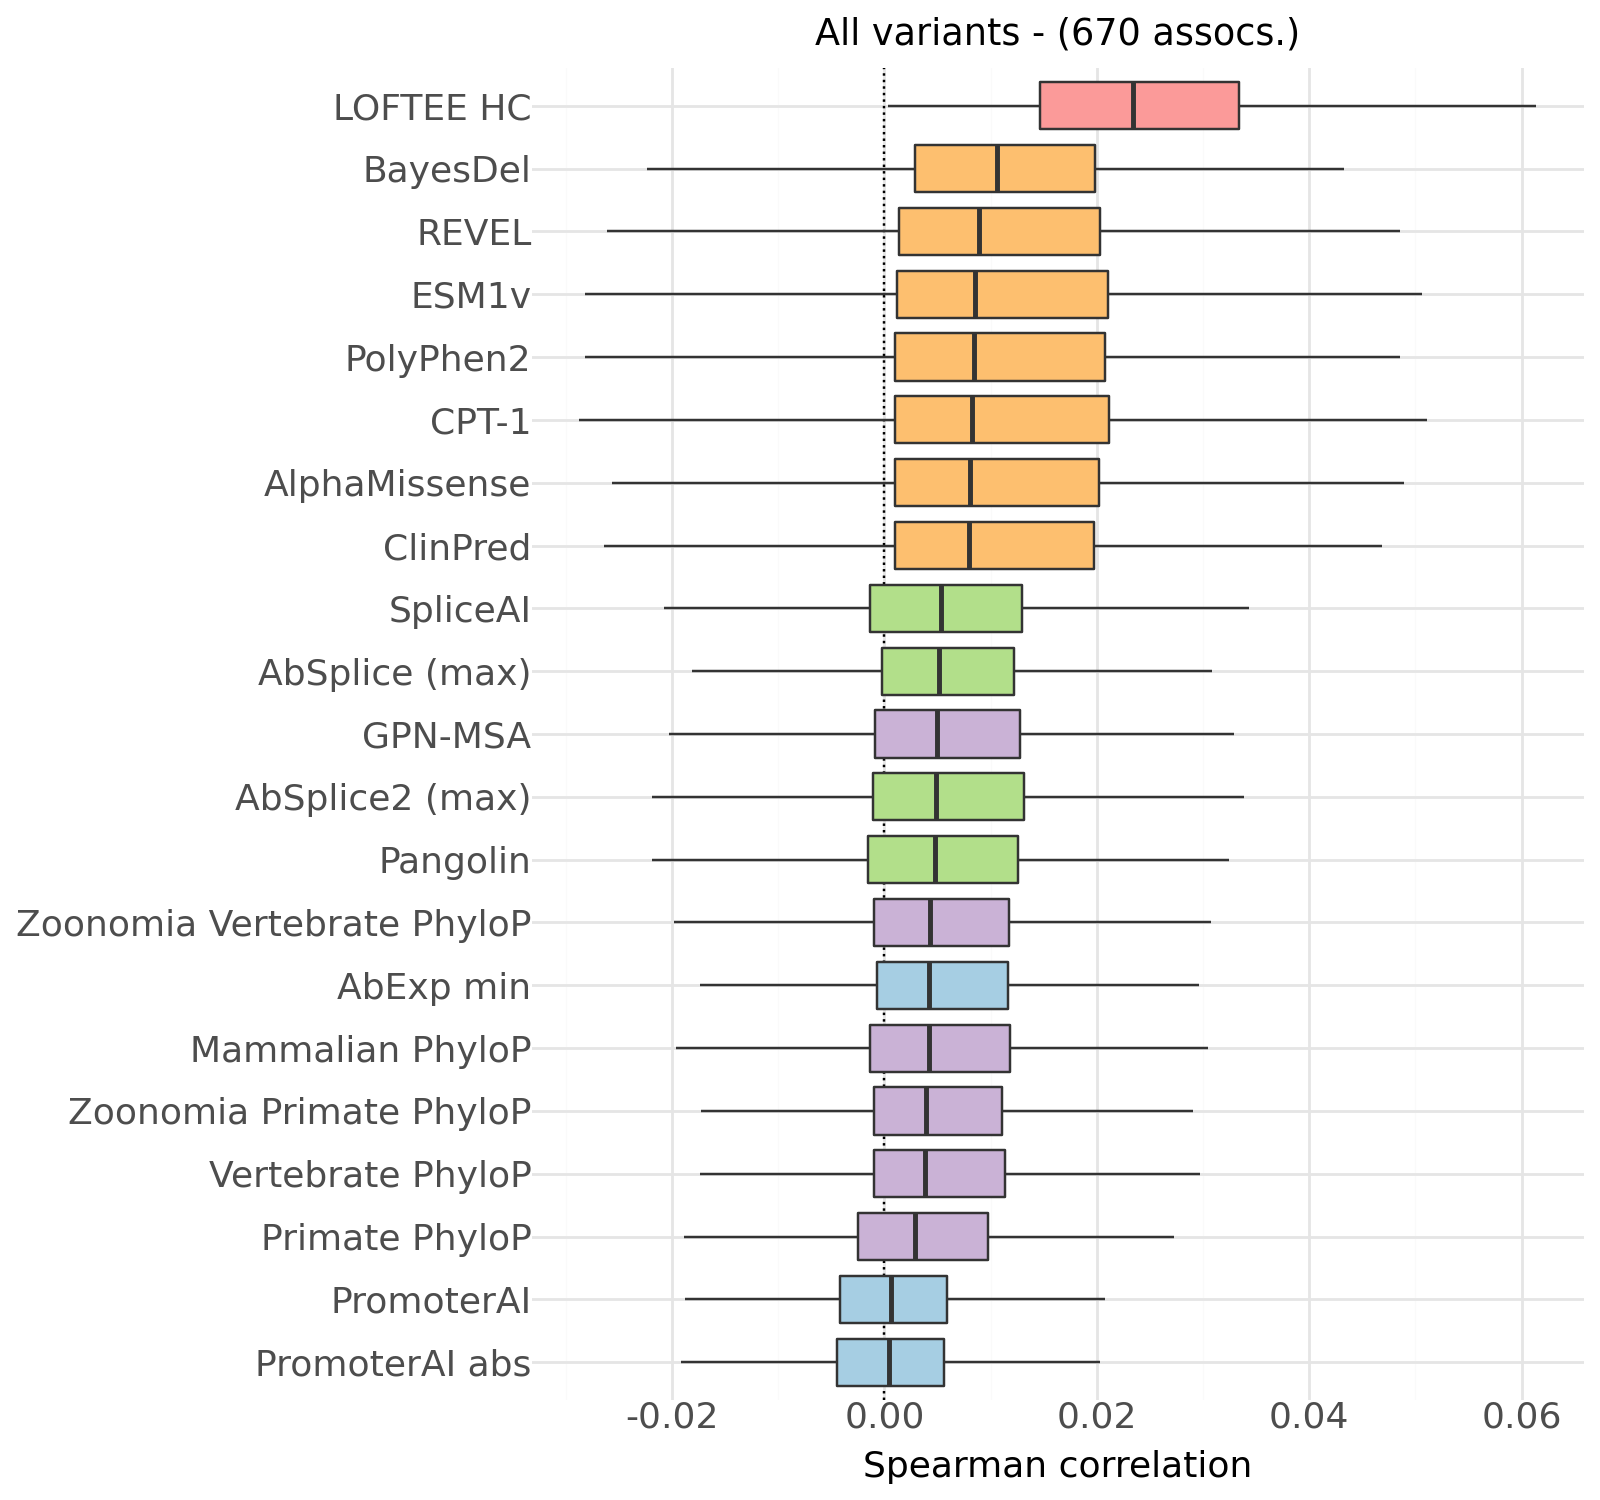

In [18]:
plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

if exclude_clinvar:
    plot_title = f"{vc['x_label']} (no ClinVar)"
elif only_clinvar:
    plot_title = f"{vc['x_label']} (only ClinVar)"
else:
    plot_title = vc['x_label']

cat_colors = pl.DataFrame({
    "category": config["correlation_categories"].keys(),
    "color": config["correlation_categories"].values(),
})
filt_corr_df = (
    filt_corr_df
    .drop('color')
    .join(
        cat_colors,
        on='category',
        how='left'
    )
)

# Calculate medians and join back
exclude_annos = ['promoterai_over', 'abexp_max'] #+ ['abexp_min', 'zooverphylop', 'zoopriphylop', 'priphylop', 'mamphylop']
plot_corr_pl = (
    filt_corr_df
    .drop_nans()
    .filter(~pl.col('annotation').is_in(exclude_annos))
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)


# 2. Determine the categorical order for the labels
ordered_labels = (
    plot_corr_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
plot_corr_pl = plot_corr_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

# 4. Create the color dictionary (Polars style)
color_dict = dict(plot_corr_pl.select("annotation", "color").unique().iter_rows())

# Plot
(
    ggplot(plot_corr_pl, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    # + geom_boxplot(alpha=0.7)
    + geom_boxplot(alpha=1, outlier_shape=None)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{plot_title} variants - ({plot_corr_pl['region'].n_unique()} assocs.)",
    )
    + coord_flip()
    + theme(
        figure_size=(8, plot_corr_pl['annotation'].n_unique()/3 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

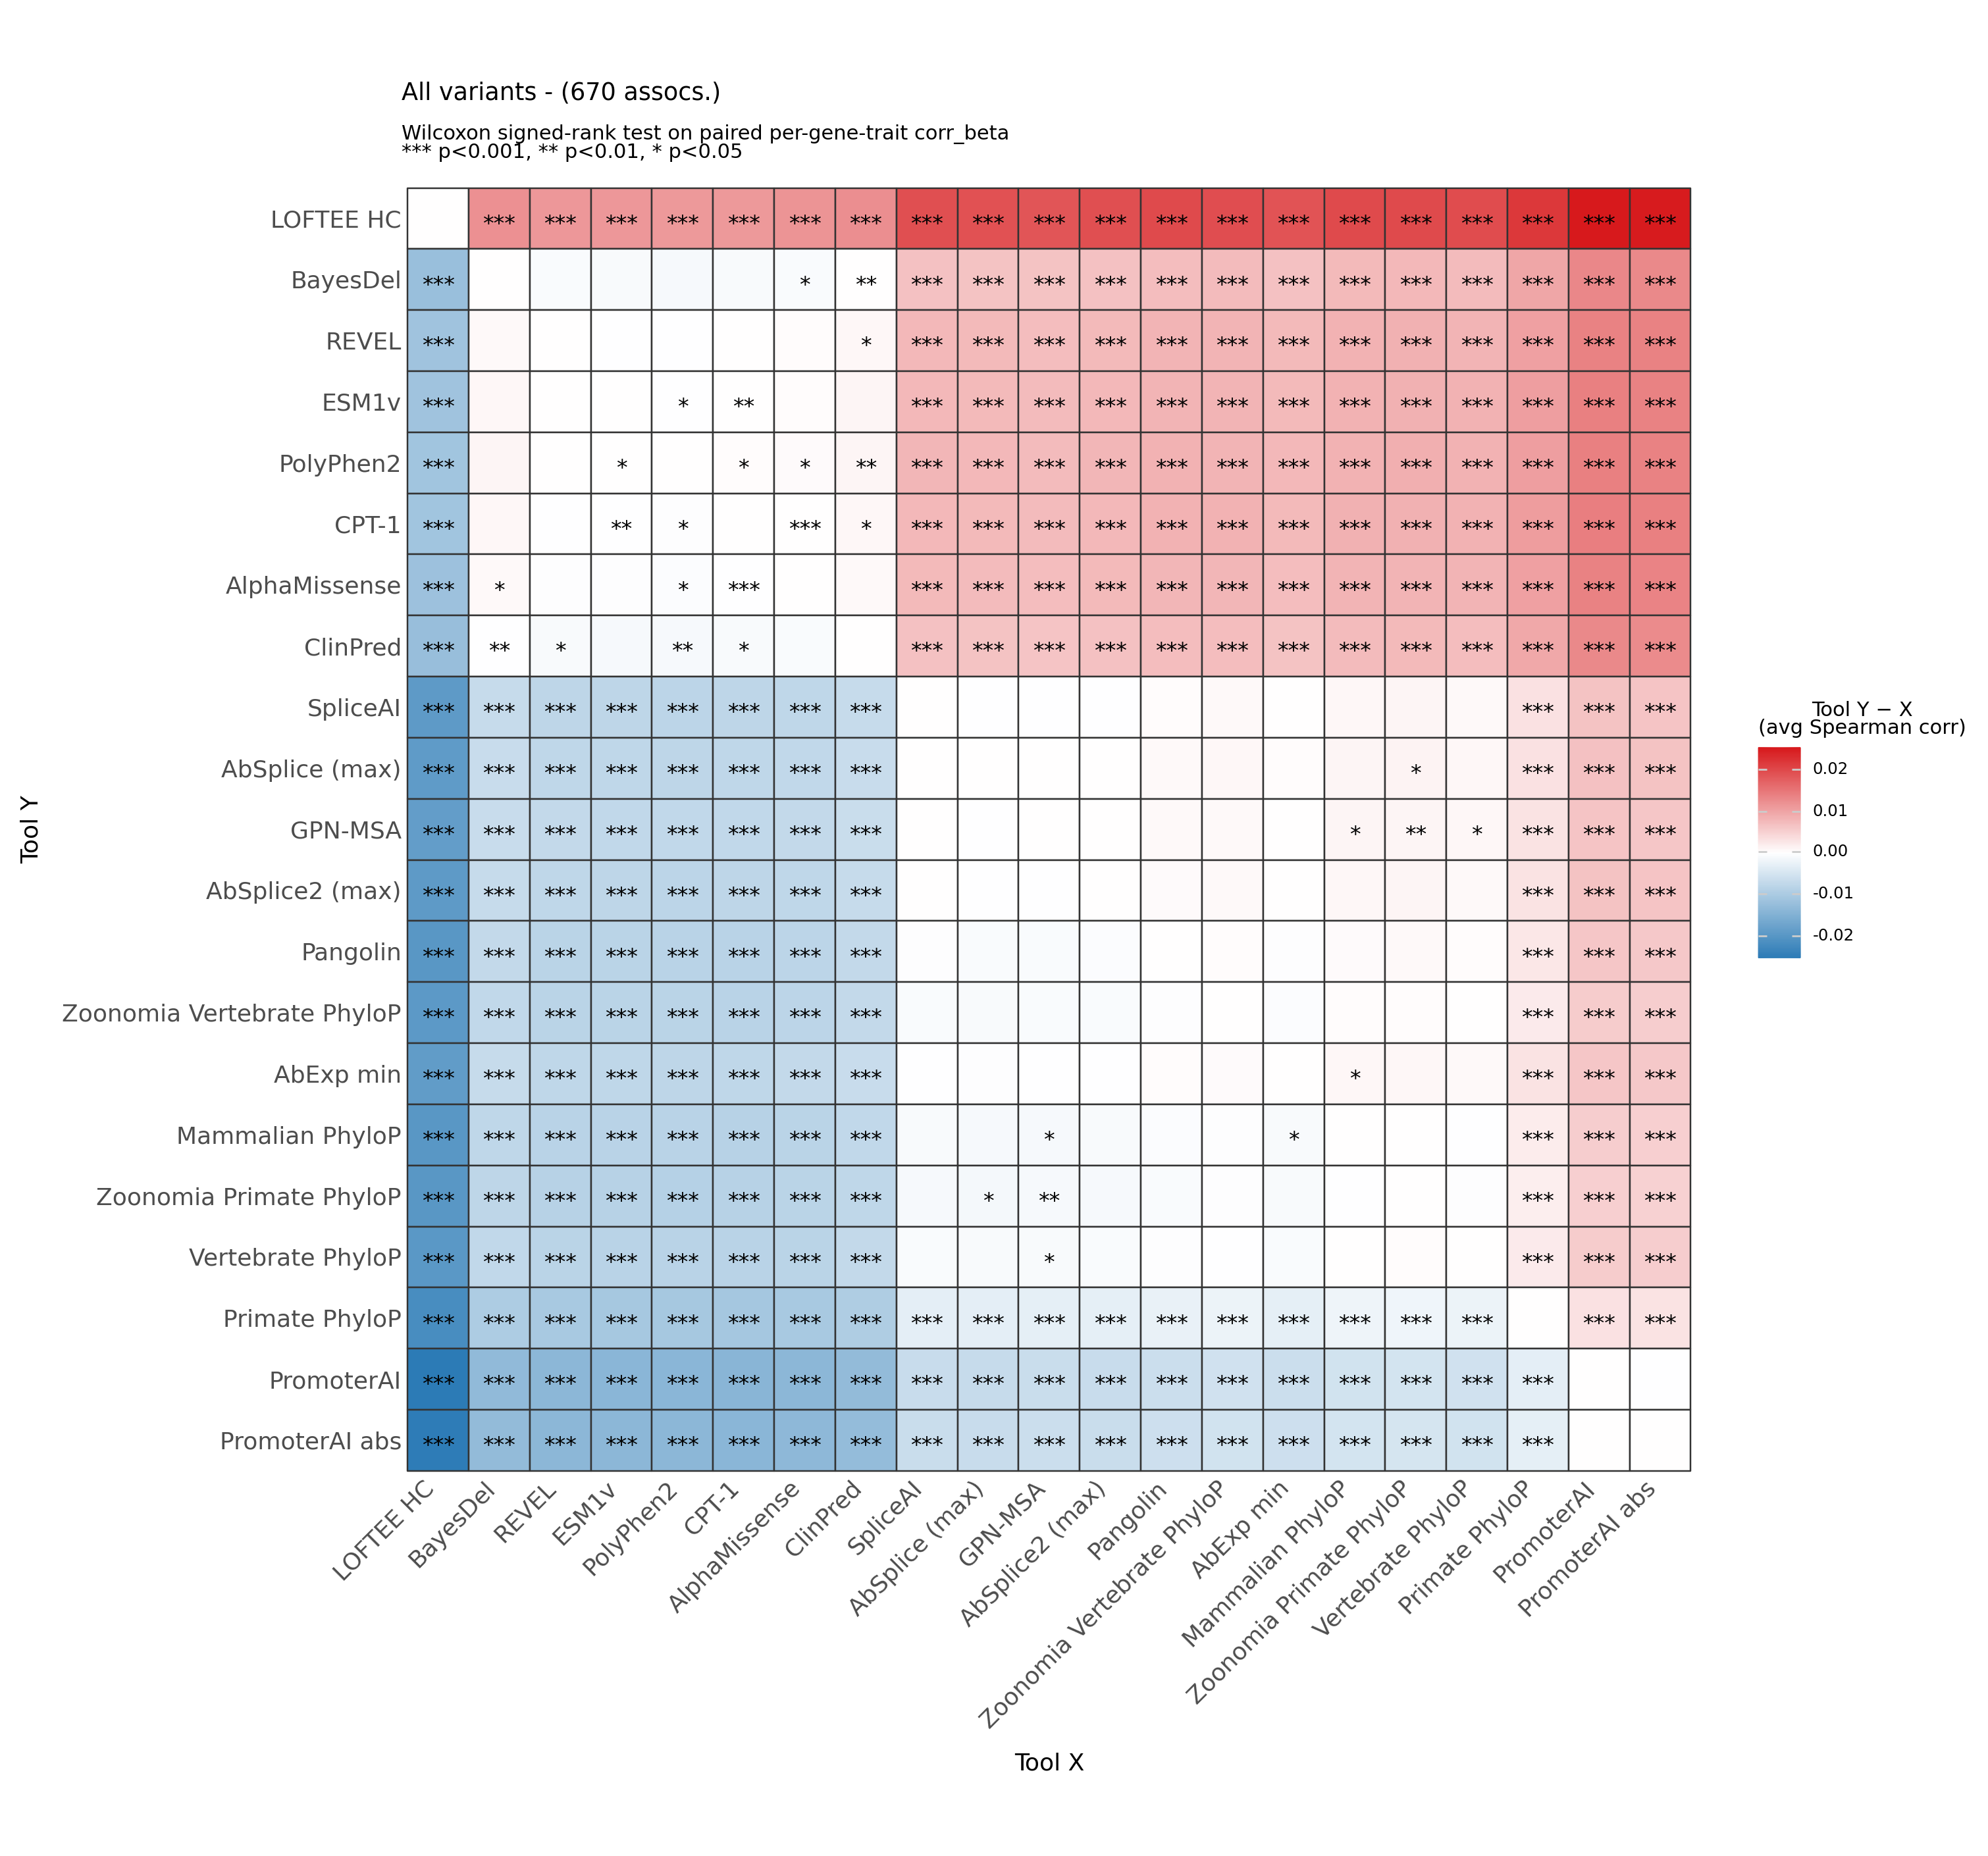

In [12]:
import pandas as pd
import itertools
import numpy as np
from scipy import stats

# --- 1. Determine annotation set and ordering ---
plot_annotations = plot_corr_pl.select("annotation").unique().to_series().to_list()


# Filter tools
plot_annotations = [a for a in plot_annotations if a not in exclude_annos]

# Build annotation -> label mapping
anno_to_label = dict(
    plot_corr_pl.select(["annotation", "label"]).unique().iter_rows()
)

# Order tools by median corr_beta (best first)
tool_medians = {}
for ann in plot_annotations:
    vals = plot_corr_pl.filter(pl.col("annotation") == ann)["corr_beta"].to_numpy()
    tool_medians[ann] = float(np.nanmedian(vals))

ordered_tools  = sorted(tool_medians.keys(), key=lambda x: tool_medians[x], reverse=True)
ordered_labels = [anno_to_label.get(t, t) for t in ordered_tools]

# --- 2. Pairwise Wilcoxon signed-rank test on paired (region, phenotype) corr_beta ---
heatmap_data = []

for ann_x, ann_y in itertools.product(ordered_tools, repeat=2):
    label_x = anno_to_label.get(ann_x, ann_x)
    label_y = anno_to_label.get(ann_y, ann_y)

    if ann_x == ann_y:
        heatmap_data.append({
            'Tool_X': label_x,
            'Tool_Y': label_y,
            'mean_diff': 0.0,
            'sig': ''
        })
        continue

    # Inner join on (region, phenotype) to get paired values
    df_x = plot_corr_pl.filter(pl.col("annotation") == ann_x).select(["region", "phenotype", "corr_beta"])
    df_y = plot_corr_pl.filter(pl.col("annotation") == ann_y).select(["region", "phenotype", "corr_beta"])

    paired = df_x.join(df_y, on=["region", "phenotype"], suffix="_y")
    c_x = paired["corr_beta"].to_numpy()
    c_y = paired["corr_beta_y"].to_numpy()

    mean_diff = float(c_y.mean() - c_x.mean())

    if len(c_x) >= 10 and not np.allclose(c_x, c_y):
        _, p_val = stats.wilcoxon(c_x, c_y, alternative='two-sided')
    else:
        p_val = 1.0

    if   p_val < 0.001: sig = '***'
    elif p_val < 0.01:  sig = '**'
    elif p_val < 0.05:  sig = '*'
    else:               sig = ''

    heatmap_data.append({
        'Tool_X': label_x,
        'Tool_Y': label_y,
        'mean_diff': mean_diff,
        'sig': sig
    })

df_heat = pd.DataFrame(heatmap_data)

# Lock in categorical order so best tools appear top/right
df_heat['Tool_X'] = pd.Categorical(df_heat['Tool_X'], categories=ordered_labels,       ordered=True)
df_heat['Tool_Y'] = pd.Categorical(df_heat['Tool_Y'], categories=ordered_labels[::-1], ordered=True)

n_tools = len(ordered_tools)

# --- 3. Plot ---
(
    ggplot(df_heat, aes(x='Tool_X', y='Tool_Y', fill='mean_diff'))
    + geom_tile(color="#333333", size=0.5)
    + geom_text(aes(label='sig'), color="black", size=12, va='center', nudge_y=-0.1)
    + scale_fill_gradient2(low="#2C7BB6", mid="#FFFFFF", high="#D7191C", midpoint=0)
    + labs(
        title=f"{plot_title} variants - ({plot_corr_pl['region'].n_unique()} assocs.)",
        subtitle="Wilcoxon signed-rank test on paired per-gene-trait corr_beta\n*** p<0.001, ** p<0.01, * p<0.05",
        x="Tool X",
        y="Tool Y",
        fill="Tool Y \u2212 X\n(avg Spearman corr)"
    )
    + theme_minimal()
    + theme(
        figure_size=(n_tools * 0.6 + 2.5, n_tools * 0.6 + 1.5),
        aspect_ratio=1,
        axis_title=element_text(size=13),
        axis_text=element_text(size=13),
        axis_text_x=element_text(rotation=45, hjust=1),
        panel_grid=element_blank(),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [13]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_219687/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""loftee_hc""","""promoterai_under""",668,1360.0,2.0827e-108
"""promoterai_abs""","""loftee_hc""",668,1627.0,6.8090e-108
"""priphylop""","""loftee_hc""",670,2851.0,6.8119e-106
"""zoopriphylop""","""loftee_hc""",670,3169.0,2.7283e-105
"""loftee_hc""","""mamphylop""",670,4006.0,1.0321e-103
…,…,…,…,…
"""cpt1_llr""","""polyphen""",623,87585.0,0.032623
"""revel_score""","""clinpred_score""",658,98088.0,0.034421
"""bayes_del""","""am_pathogenicity""",648,95207.0,0.037238


# Stratify by LOEUF score

In [14]:
gnom = (
    pl.read_csv(
        "/home/dnanexus/data_dir/gnomad.v4.1.constraint_metrics.tsv", 
        null_values=["NA"],
        separator='\t'
    )
    .filter(
        pl.col('transcript_type')=='protein_coding',
        pl.col('canonical')==True
        # pl.col('mane_select')==True
    )
    .select(['gene_id', 'lof.oe_ci.upper'])
    .rename({'gene_id': 'region', 'lof.oe_ci.upper': 'loeuf'})
    .drop_nulls()
)

gnom

region,loeuf
str,f64
"""ENSG00000121410""",1.34
"""ENSG00000148584""",0.825
"""ENSG00000175899""",0.765
"""ENSG00000166535""",0.953
"""ENSG00000184389""",1.529
…,…
"""ENSG00000288914""",1.87
"""ENSG00000289027""",0.885
"""ENSG00000289258""",0.982


In [15]:
set(correlation_df['region'].unique()) - set(gnom['region'].unique())

{'ENSG00000162600'}

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 19'. Pick better value with 'binwidth'.


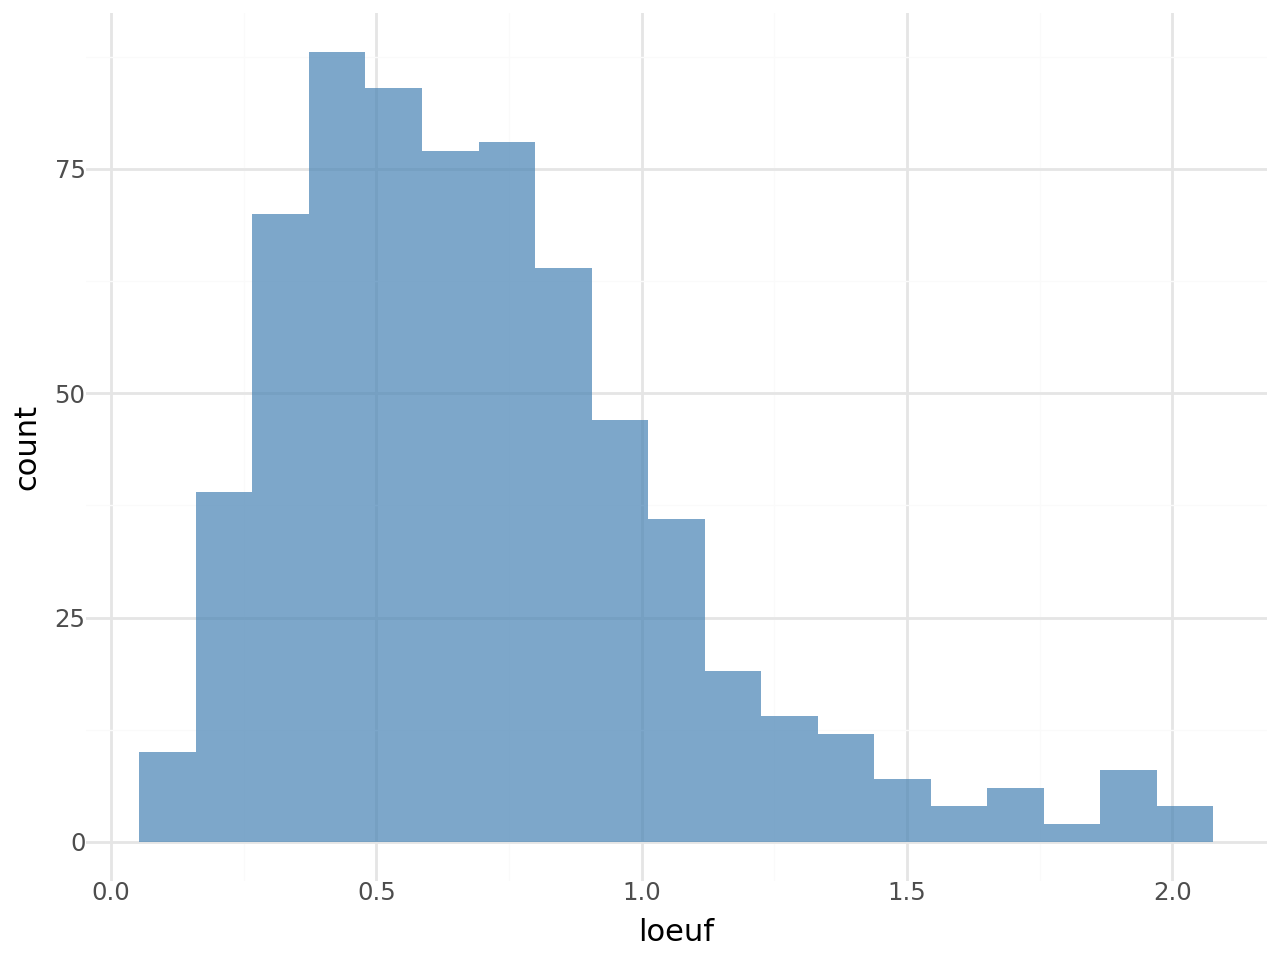

In [16]:
tmp = gnom.join(correlation_df.select(['region']).unique(), on='region', how='inner').with_columns(subset=pl.lit('ukbbgym_pheno'))

(
    ggplot(tmp, aes(x='loeuf'))
    + geom_histogram(position='identity', fill='steelblue', alpha=0.7)
    + theme_minimal()
)

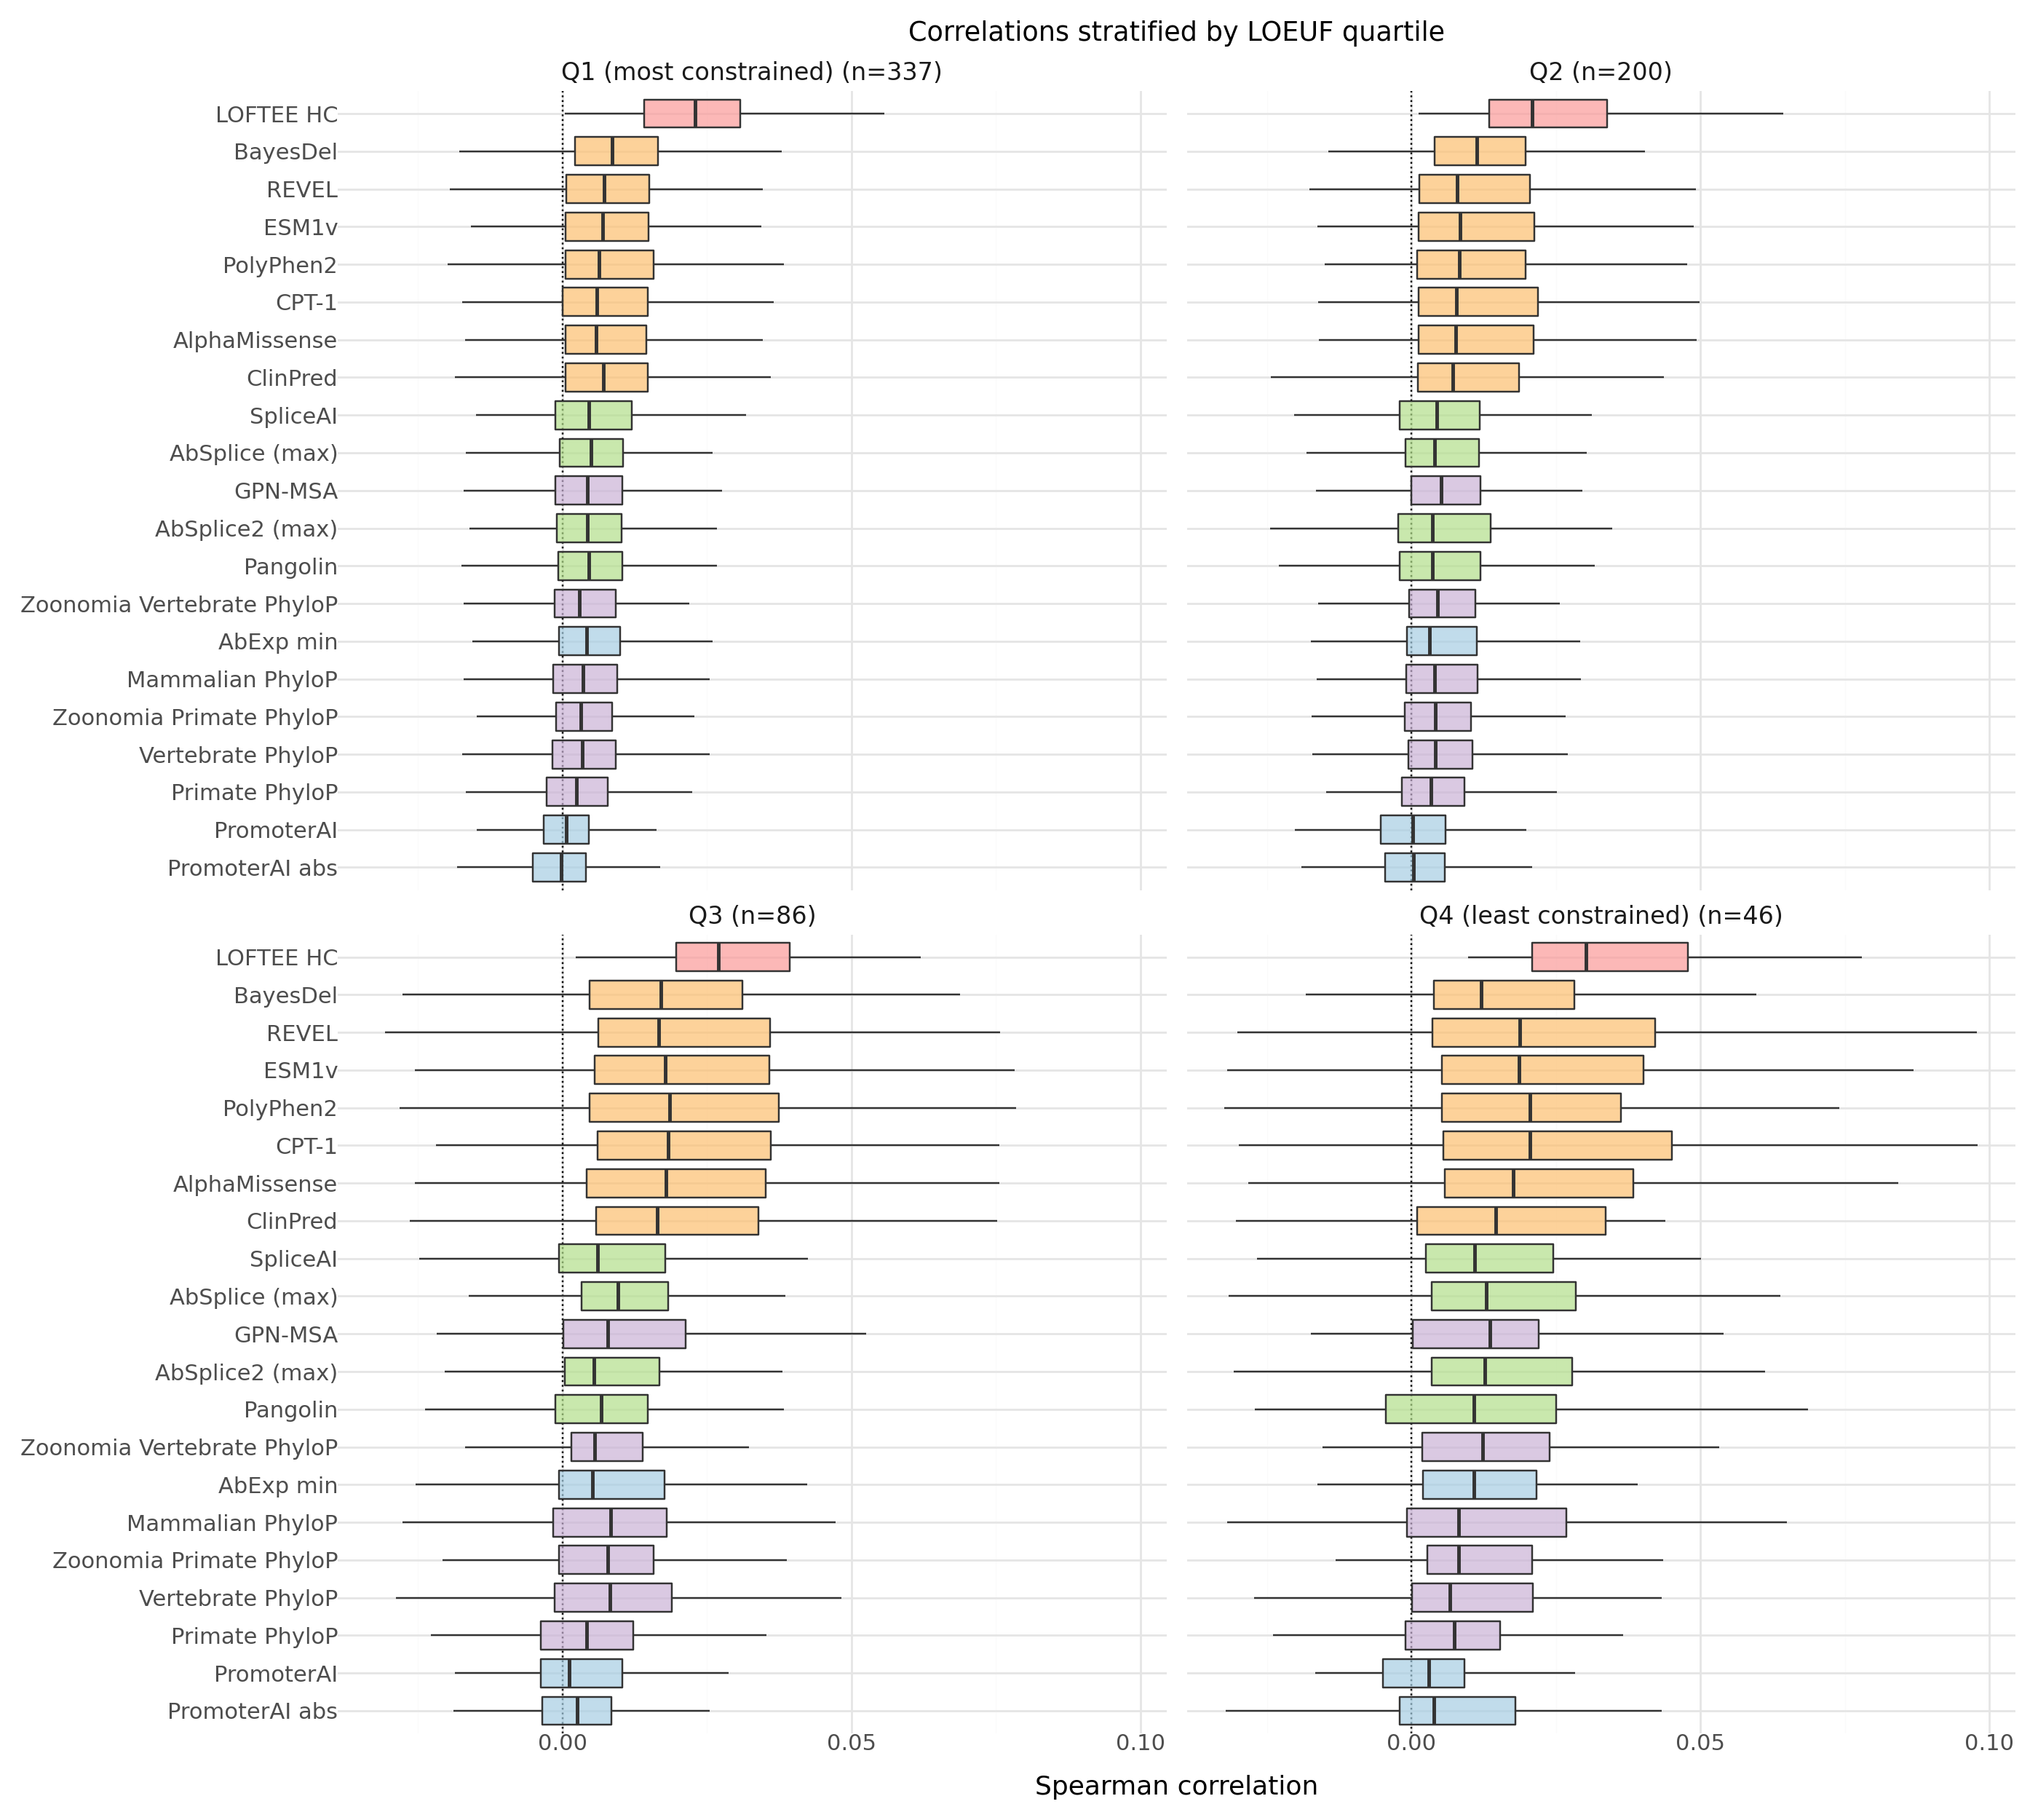

In [17]:
# Create 4 LOEUF bins from the full gnomAD constraint table
loeuf_bins = gnom.with_columns(
    loeuf_bin = pl.col('loeuf').qcut(4, labels=['Q1 (most constrained)', 'Q2', 'Q3', 'Q4 (least constrained)'])
)

# Join LOEUF bins to filt_corr_df
corr_loeuf = (
    filt_corr_df
    .join(loeuf_bins, on='region', how='inner')
    .drop_nans()
)

# Add n= counts to the bin labels
bin_counts = (
    corr_loeuf
    .select(['region', 'phenotype', 'loeuf_bin'])
    .unique(subset=['region', 'phenotype'])
    .group_by('loeuf_bin')
    .len()
)
bin_label_map = {
    row[0]: f"{row[0]} (n={row[1]})" for row in bin_counts.iter_rows()
}
corr_loeuf = corr_loeuf.with_columns(
    pl.col('loeuf_bin').cast(pl.Utf8).replace(bin_label_map).alias('loeuf_bin')
)

plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Order annotations by overall median
corr_loeuf_pl = corr_loeuf.with_columns(
    median_corr_beta = pl.col(plotting_col).median().over("annotation")
)

ordered_labels = (
    corr_loeuf_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

corr_loeuf_pl = corr_loeuf_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

color_dict = dict(corr_loeuf_pl.select("annotation", "color").unique().iter_rows())

(
    ggplot(corr_loeuf_pl, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + facet_wrap("~loeuf_bin", ncol=2)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"Correlations stratified by LOEUF quartile"
    )
    + coord_flip()
    + theme(
        figure_size=(14, corr_loeuf_pl['annotation'].n_unique()/2 + 2),
        legend_position="none",
        axis_text=element_text(size=11),
        axis_title=element_text(size=13),
        strip_text=element_text(size=12),
        plot_background=element_rect(fill="white", color="white"),
    )
)